<a href="https://colab.research.google.com/github/sambee5/data-science-coursework/blob/main/Unit7/SamaBhatU7Proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting On-Time Compliance for Austin EMS for Priority 4 Indicents



The dataset I have here covers the EMS incident reports across Austin and Travis county, seperated into different priority levels and tracked over time. Something I'm interested in within the data is if as time increases, the number of incidents does too.

While this may seem obvious, this is interested to me because it could be possible that a higher population yields a more safe response. I'm also curious about the trends during COVID, since there was a lot of movement into Austin during that time, even if there was a global health crisis. I wonder how Austin may have handled that.

In [ ]:
!pip install preliz
!pip install bambi

In [2]:
import numpy as np
import pandas as pd
import arviz as az
import pymc as pm
import graphviz as gv
import matplotlib.pyplot as plt
import seaborn as sns
import bambi as bmb

In [3]:
d = pd.read_csv("https://raw.githubusercontent.com/sambee5/data-science-coursework/refs/heads/main/Unit7/EMS_-_Incidents_by_Month_20260316.csv")
d = d.dropna(axis=1, how='all')

In [4]:
d

,Month Key,Month-Year,Total Incidents,Austin Incidents,Travis County Incidents,Other Area Incidents,Combined Austin and Travis County Incidents,Austin P1 Incidents,Austin P2 Incidents,Austin P3 Incidents,...,Austin P2 On-Time Compliance,Austin P3 On-Time Compliance,Austin P4 On-Time Compliance,Austin P5 On-Time Compliance,Travis County P1 On-Time Compliance,Travis County P2 On-Time Compliance,Travis County P3 On-Time Compliance,Travis County P4 On-Time Compliance,Travis County P5 On-Time Compliance,Target On-Time Compliance
0,201010,Oct 2010,"8,910","7,571","1,321",18,"8,892",533,"2,103","1,039",...,96.78%,99.26%,98.82%,94.57%,79.73%,77.22%,89.77%,95.67%,88.11%,90%
1,201011,Nov 2010,"7,826","6,564","1,232",30,"7,796",401,"1,896",931,...,96.73%,98.94%,98.43%,95.49%,80.77%,82.97%,89.10%,96.75%,92.91%,90%
2,201012,Dec 2010,"8,182","6,858","1,290",34,"8,148",458,"1,892",903,...,96.63%,98.67%,98.24%,94.50%,75.28%,81.85%,86.34%,96.04%,92.54%,90%
3,201101,Jan 2011,"8,287","7,081","1,185",21,"8,266",466,"2,017","1,025",...,96.34%,97.99%,98.82%,95.25%,66.67%,86.82%,90.80%,94.43%,88.10%,90%
4,201102,Feb 2011,"8,241","6,969","1,255",17,"8,224",426,"2,058",982,...,96.18%,97.78%,97.97%,92.52%,64.38%,81.07%,85.31%,93.75%,88.59%,90%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,202510,Oct 2025,"11,516","9,713","1,677",126,"11,390",662,"1,164","2,810",...,79.70%,84.22%,72.35%,95.37%,59.43%,77.73%,83.72%,77.01%,95.56%,90%
181,202511,Nov 2025,"10,750","9,046","1,561",143,"10,607",705,"1,050","2,588",...,82.49%,85.53%,74.56%,95.86%,67.39%,82.08%,88.89%,79.06%,100.00%,90%
182,202512,Dec 2025,"11,204","9,396","1,674",134,"11,070",711,"1,218","2,539",...,79.30%,86.23%,76.99%,95.93%,67.31%,78.17%,85.77%,80.03%,98.11%,90%
183,202601,Jan 2026,"11,126","9,332","1,643",151,"10,975",481,"1,111","2,735",...,83.62%,86.10%,77.14%,96.90%,61.84%,82.84%,81.95%,80.28%,96.74%,90%


In [5]:
d.columns = d.columns.str.replace(' ', '_')
d.head()

,Month_Key,Month-Year,Total_Incidents,Austin_Incidents,Travis_County_Incidents,Other_Area_Incidents,Combined_Austin_and_Travis_County_Incidents,Austin_P1_Incidents,Austin_P2_Incidents,Austin_P3_Incidents,...,Austin_P2_On-Time_Compliance,Austin_P3_On-Time_Compliance,Austin_P4_On-Time_Compliance,Austin_P5_On-Time_Compliance,Travis_County_P1_On-Time_Compliance,Travis_County_P2_On-Time_Compliance,Travis_County_P3_On-Time_Compliance,Travis_County_P4_On-Time_Compliance,Travis_County_P5_On-Time_Compliance,Target_On-Time_Compliance
0,201010,Oct 2010,"8,910","7,571","1,321",18,"8,892",533,"2,103","1,039",...,96.78%,99.26%,98.82%,94.57%,79.73%,77.22%,89.77%,95.67%,88.11%,90%
1,201011,Nov 2010,"7,826","6,564","1,232",30,"7,796",401,"1,896",931,...,96.73%,98.94%,98.43%,95.49%,80.77%,82.97%,89.10%,96.75%,92.91%,90%
2,201012,Dec 2010,"8,182","6,858","1,290",34,"8,148",458,"1,892",903,...,96.63%,98.67%,98.24%,94.50%,75.28%,81.85%,86.34%,96.04%,92.54%,90%
3,201101,Jan 2011,"8,287","7,081","1,185",21,"8,266",466,"2,017","1,025",...,96.34%,97.99%,98.82%,95.25%,66.67%,86.82%,90.80%,94.43%,88.10%,90%
4,201102,Feb 2011,"8,241","6,969","1,255",17,"8,224",426,"2,058",982,...,96.18%,97.78%,97.97%,92.52%,64.38%,81.07%,85.31%,93.75%,88.59%,90%


In [6]:
d['Total_Incidents'] = d['Austin_P2_Incidents'].str.replace(',', '').astype(float)

In [7]:
d['Austin_P2_Incidents'] = d['Austin_P2_Incidents'].str.replace(',', '').astype(float)
d['Austin_P4_On-Time_Compliance'] = d['Austin_P4_On-Time_Compliance'].str.replace('%', '').astype(float) / 100
d.head()

,Month_Key,Month-Year,Total_Incidents,Austin_Incidents,Travis_County_Incidents,Other_Area_Incidents,Combined_Austin_and_Travis_County_Incidents,Austin_P1_Incidents,Austin_P2_Incidents,Austin_P3_Incidents,...,Austin_P2_On-Time_Compliance,Austin_P3_On-Time_Compliance,Austin_P4_On-Time_Compliance,Austin_P5_On-Time_Compliance,Travis_County_P1_On-Time_Compliance,Travis_County_P2_On-Time_Compliance,Travis_County_P3_On-Time_Compliance,Travis_County_P4_On-Time_Compliance,Travis_County_P5_On-Time_Compliance,Target_On-Time_Compliance
0,201010,Oct 2010,2103.0,"7,571","1,321",18,"8,892",533,2103.0,"1,039",...,96.78%,99.26%,0.9882,94.57%,79.73%,77.22%,89.77%,95.67%,88.11%,90%
1,201011,Nov 2010,1896.0,"6,564","1,232",30,"7,796",401,1896.0,931,...,96.73%,98.94%,0.9843,95.49%,80.77%,82.97%,89.10%,96.75%,92.91%,90%
2,201012,Dec 2010,1892.0,"6,858","1,290",34,"8,148",458,1892.0,903,...,96.63%,98.67%,0.9824,94.50%,75.28%,81.85%,86.34%,96.04%,92.54%,90%
3,201101,Jan 2011,2017.0,"7,081","1,185",21,"8,266",466,2017.0,"1,025",...,96.34%,97.99%,0.9882,95.25%,66.67%,86.82%,90.80%,94.43%,88.10%,90%
4,201102,Feb 2011,2058.0,"6,969","1,255",17,"8,224",426,2058.0,982,...,96.18%,97.78%,0.9797,92.52%,64.38%,81.07%,85.31%,93.75%,88.59%,90%


I need to format all the numbers into strings so I can process them properly. I used some Gemini for this.

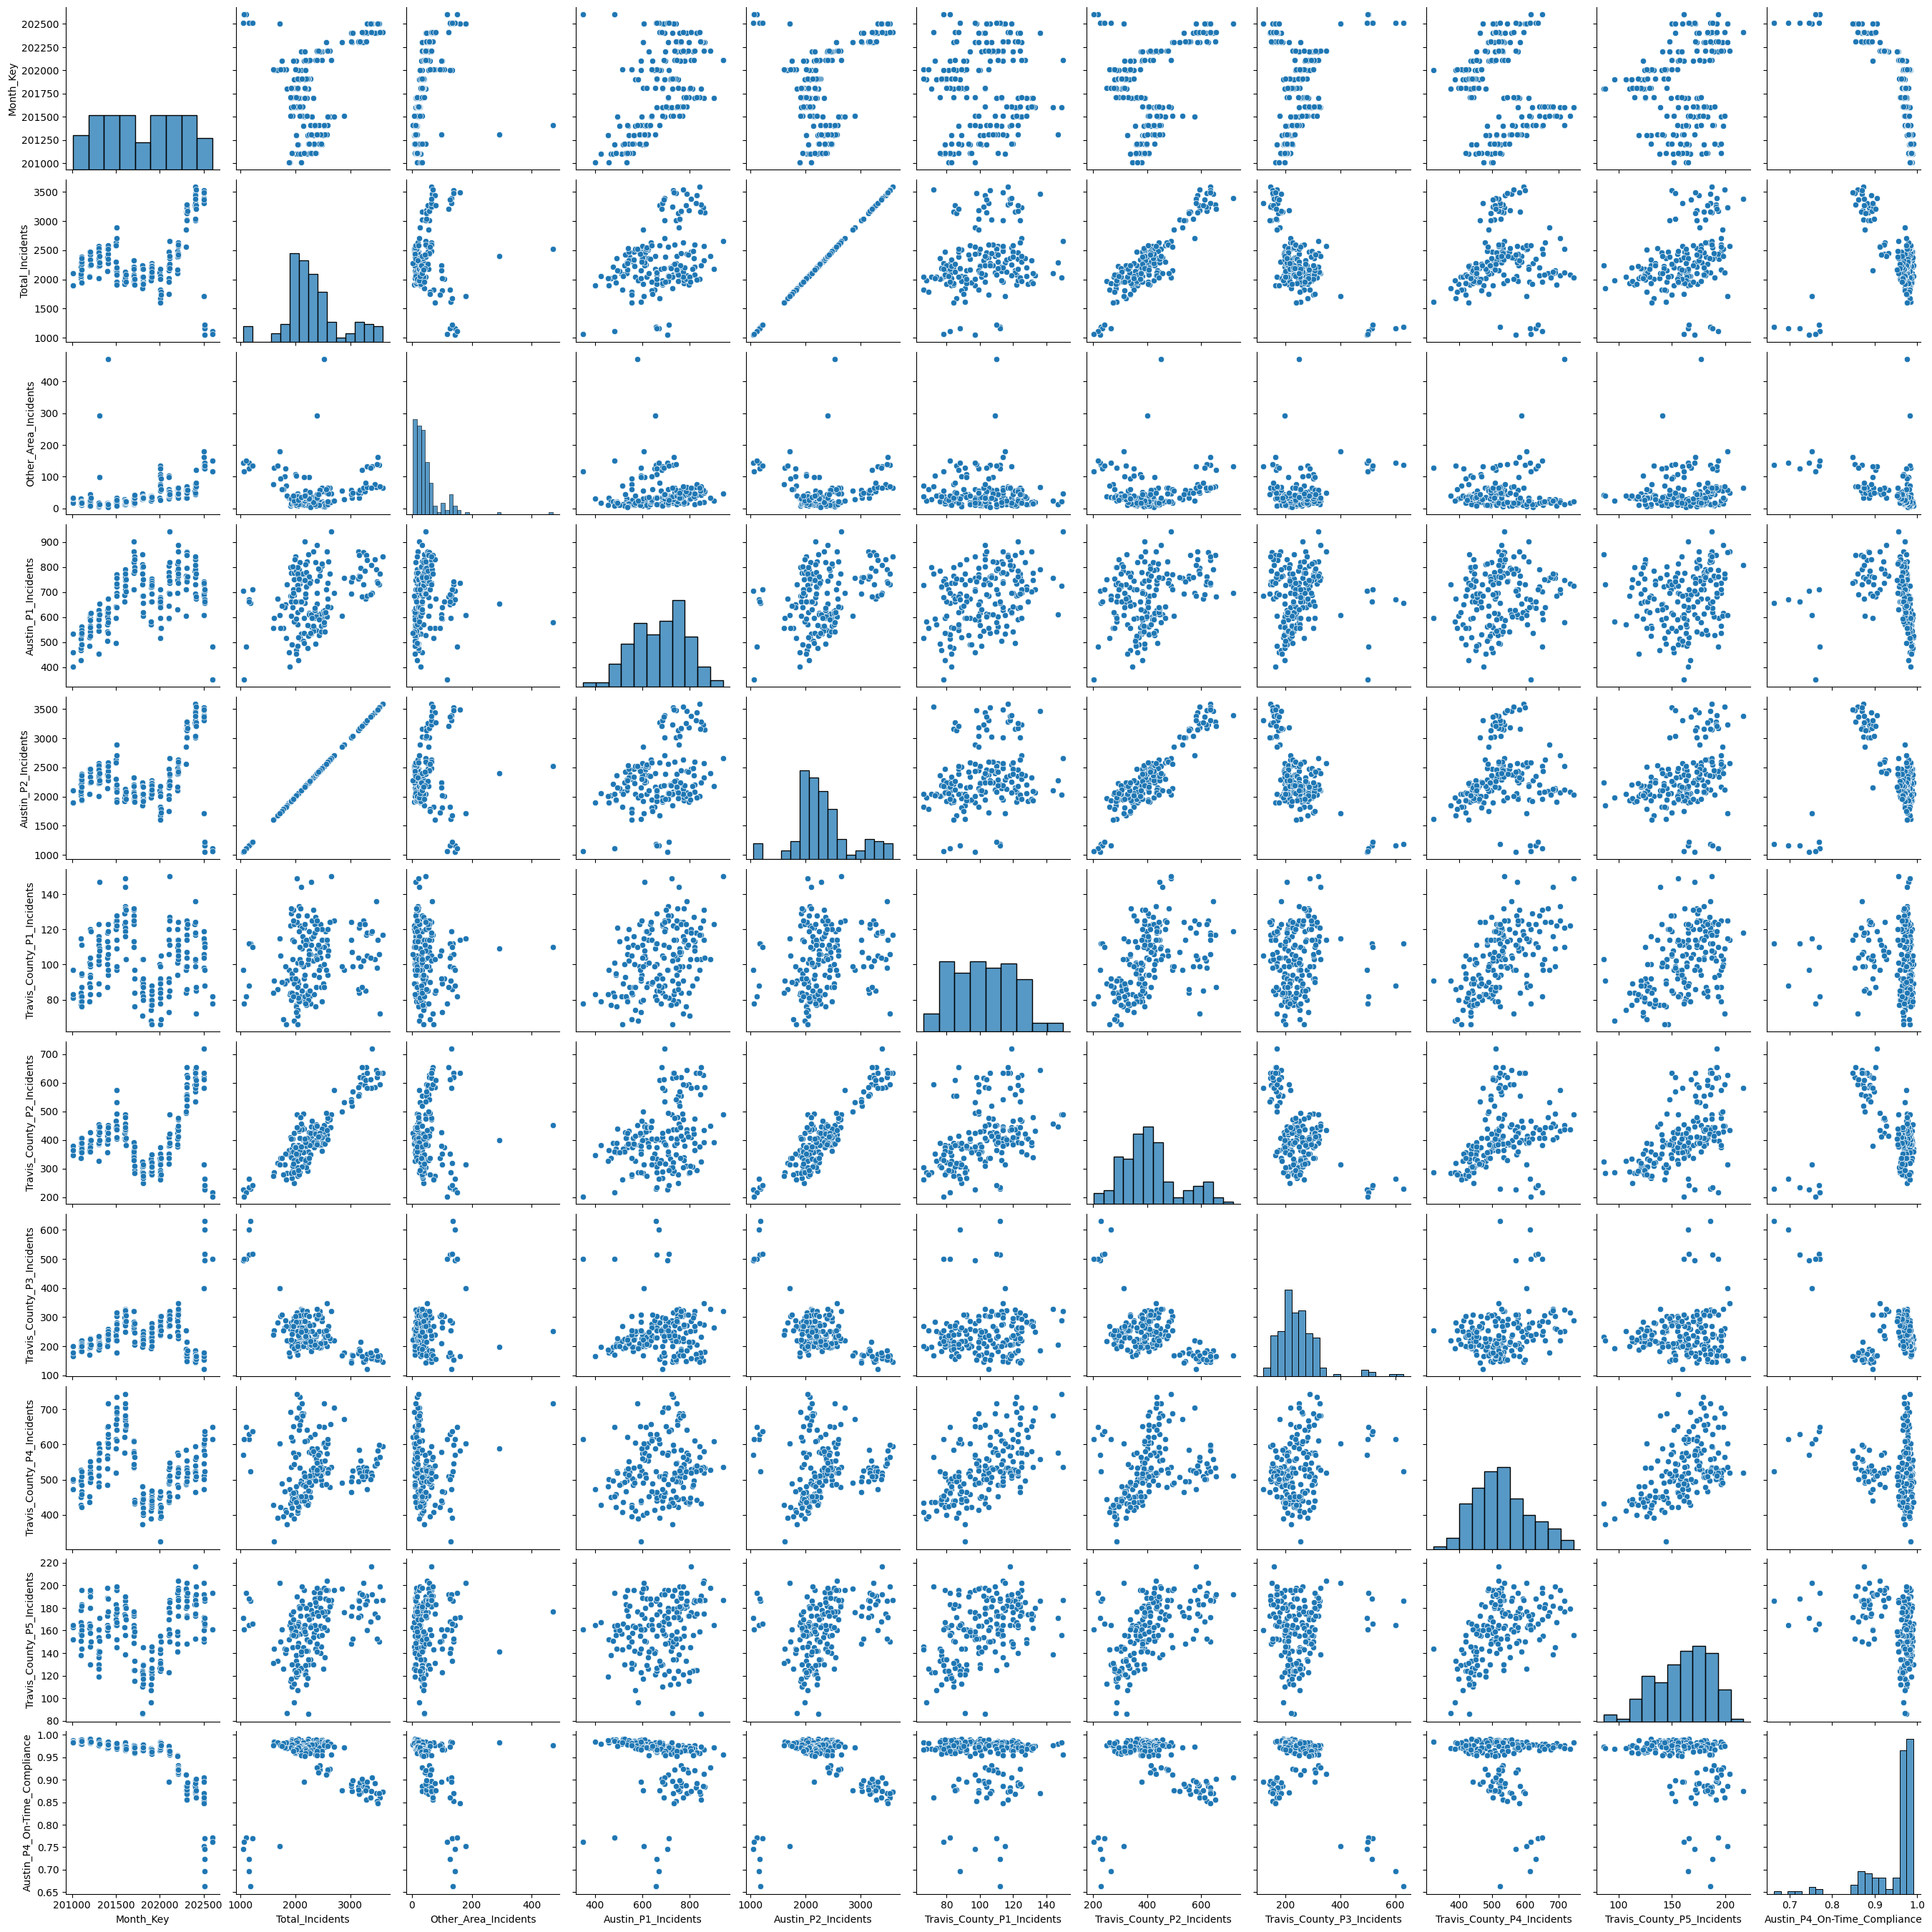

In [8]:
sns.pairplot(d)

At first glance, it seems ilke there are a lot of interesting relationships to unpack here. There are some linear relationships, but there are plenty of nonlinear ones too such as Austin P4 (priority 4) ontime compliance. This one is interesting because it makes me think Austin is getting pretty sloppy at handling "low" priority incidents as population increases.

Note: I may use time and population interchangeably because I'm considering time as a proxy for population. This is because population trends indicate that the population of Austin is increasing over time. What would be REALLY cool is if the rate at which Austin misses low priority incidents is directly correlated with the population growth.

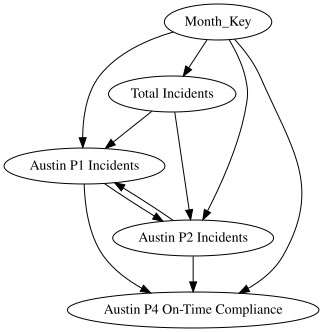

In [9]:
causal_dag = gv.Digraph(comment='Austin EMS Causal Diagram')


causal_dag.node('Time', 'Month_Key')
causal_dag.node('Total Incidents', 'Total Incidents')
causal_dag.node('Austin P1 Incidents', 'Austin P1 Incidents')
causal_dag.node('Austin P2 Incidents', 'Austin P2 Incidents')
causal_dag.node('Austin P4 On-Time Compliance', 'Austin P4 On-Time Compliance')

causal_dag.edge('Time', 'Total Incidents')
causal_dag.edge('Time', 'Austin P1 Incidents')
causal_dag.edge('Time', 'Austin P2 Incidents')

causal_dag.edge('Time', 'Austin P4 On-Time Compliance')

causal_dag.edge('Total Incidents', 'Austin P1 Incidents')
causal_dag.edge('Total Incidents', 'Austin P2 Incidents')


causal_dag.edge('Austin P1 Incidents', 'Austin P2 Incidents')

causal_dag.edge('Austin P1 Incidents', 'Austin P4 On-Time Compliance')

causal_dag.edge('Austin P2 Incidents', 'Austin P1 Incidents')

causal_dag.edge('Austin P2 Incidents', 'Austin P4 On-Time Compliance')


causal_dag

This is the causual diagram I felt makes the most sense. Since Austin is growing a lot, the time would inherently icncrease the number of total incidents. The number of total incidents also influences the number of priority 1 incidents because less priority 1 incidents means there are likely less total incidents. I felt that priority 1 and priority 2 incidents influence each other because if there are more priority 1 incidents, there are probably less priority 2 incidents and vice versa. Both incident types influence whether EMS is on time for priority 4 incidents (for some reason there isn't a P3 for Austin) since an ambulence would go to a more urgent incident than a less urgent one.

In [ ]:
#define the model
model_1 = bmb.Model("`Austin_P4_On-Time_Compliance` ~ `Month_Key` + `Austin_P1_Incidents` + `Austin_P2_Incidents` + `Total_Incidents` + Austin_P1_Incidents: Austin_P2_Incidents + `Total_Incidents`:`Austin_P1_Incidents` + `Total_Incidents`:`Austin_P2_Incidents`", data=d)
#fit the model
idata_model_1 = model_1.fit(idata_kwargs={'log_likelihood': True})

In [ ]:
model_poly_1 = bmb.Model('`Austin_P4_On-Time_Compliance` ~ poly(`Austin_P1_Incidents`, 3)', d, family="gaussian")
idata_poly_1 = model_poly_1.fit(idata_kwargs={"log_likelihood": True})
print("Polynomial model fitted successfully and idata_poly_1 is now available with log likelihood.")

Text(0, 0.5, 'Austin P4 On-Time Compliance')

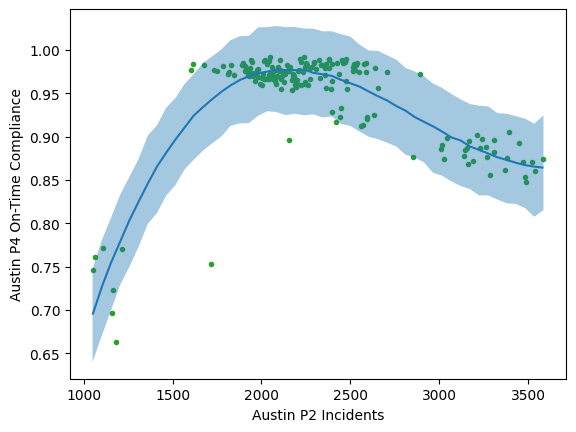

In [30]:
bmb.interpret.plot_predictions(model_poly_1, idata_poly_1, "Austin_P2_Incidents", pps=True)
plt.plot(d['Austin_P2_Incidents'], d['Austin_P4_On-Time_Compliance'], "C2.", zorder=-3)
plt.xlabel("Austin P2 Incidents")
plt.ylabel("Austin P4 On-Time Compliance")


<Axes: xlabel='Austin_P4_On-Time_Compliance'>

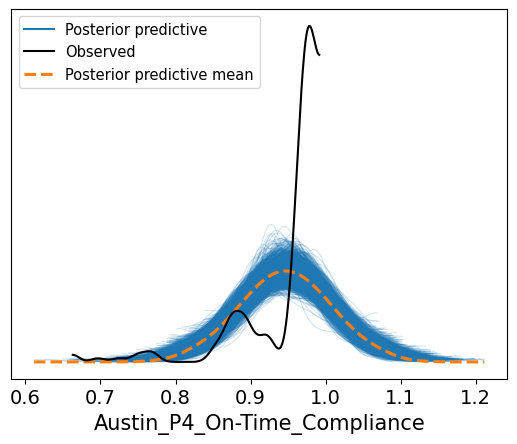

In [14]:
model_poly_1.predict(idata_poly_1, kind="response")
az.plot_ppc(idata_poly_1)

In [ ]:
#define the model
model_2 = bmb.Model("'Austin_P4_On-Time_Compliance' ~ Month_Key + Austin_P1_Incidents + Austin_P2_Incidents + Total_Incidents", data=d)
#fit the model
idata_model_2 = model_2.fit(idata_kwargs={'log_likelihood': True})

<Axes: xlabel='Austin_P4_On-Time_Compliance'>

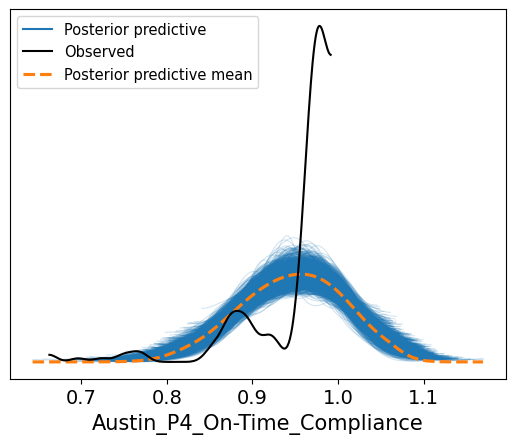

In [16]:
model_2.predict(idata_model_2, kind="response")
az.plot_ppc(idata_model_2)

In [ ]:
model_bspline = bmb.Model('`Austin_P4_On-Time_Compliance` ~ bs(`Austin_P2_Incidents`, df=5)', d, family="gaussian")
idata_bspline = model_bspline.fit(idata_kwargs={"log_likelihood": True})


Text(0, 0.5, 'Austin P4 On-Time Compliance')

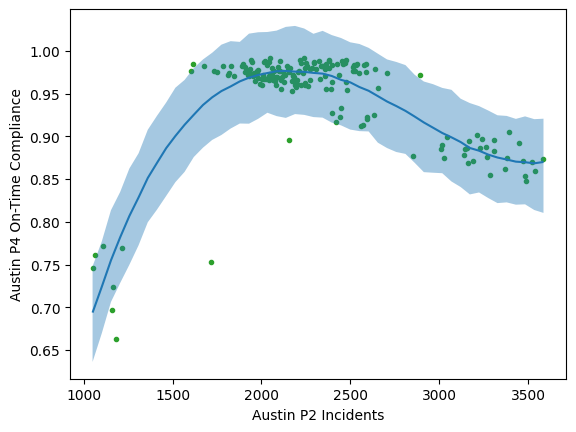

In [29]:
bmb.interpret.plot_predictions(model_bspline, idata_bspline, "Austin_P2_Incidents", pps=True)
plt.plot(d['Austin_P2_Incidents'], d['Austin_P4_On-Time_Compliance'], "C2.", zorder=-3)
plt.xlabel("Austin P2 Incidents")
plt.ylabel("Austin P4 On-Time Compliance")


/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimat

<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

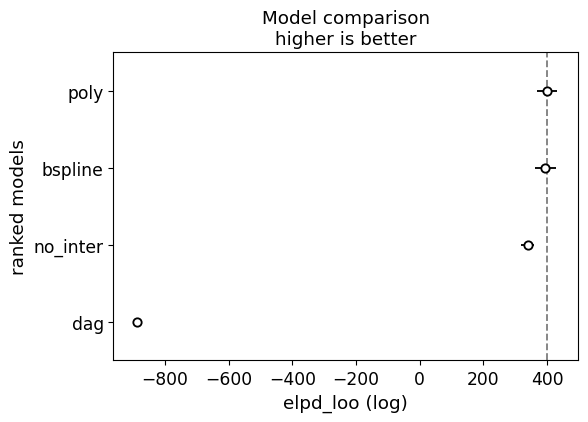

In [28]:
cmp_df = az.compare( {"dag":idata_model_1,"poly":idata_poly_1, "no_inter": idata_model_2, "bspline": idata_bspline})
az.plot_compare(cmp_df)

Conclusion--polynomial models are good for this data. Priority 2 incident count is a solid predictor for whether EMS is on time to priority 4 incidents in Austin.